# Modeling a Minecraft Skin Classifier
---

## 1. Problem Statement (Business Understanding)

### What are we solving?

Minecraft servers often need to automatically detect skins that violate copyright or community guidelines  
(e.g. skins depicting Spider-Man, other licensed characters, or inappropriate content).  
Manual review is not scalable - a Minecraft server can have thousands of players.

**Goal:** Build a binary image classifier that automatically flags a Minecraft skin as:  
- **Class 0 - normal** (generic, community-created skin)  
- **Class 1 - flagged** (depicts a copyrighted / banned character, e.g. Spider-Man)

### Why does recall matter more than precision here?

A **false negative** (flagged skin classified as normal) means a banned skin slips through → real harm.  
A **false positive** (normal skin flagged as bad) means an unfair temporary ban → recoverable harm.  

Therefore we optimize **recall** (sensitivity) while keeping precision acceptable.  
We will tune the classification **threshold** accordingly after training.

### Why CNN?

Minecraft skins are 64×64 RGBA pixel images where **spatial structure is fixed**  
(head always top-left, body always center, etc.).  
CNNs exploit local spatial correlations via shared convolutional filters, making them the natural  
choice for structured image data. They learn hierarchical features (edges → textures → shapes)  
without hand-crafted feature engineering.

Unlike a fully connected network, a CNN uses **weight sharing** and **local receptive fields**,  
which drastically reduces parameters and improves generalization on small datasets.

## Setup & Imports

We use **TensorFlow** for the deep learning pipeline and **scikit-learn** for evaluation metrics.
All random seeds are fixed for reproducibility.

In [209]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_recall_curve
from sklearn.model_selection import train_test_split

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Central Configuration

**Design decision:** All tunable parameters are defined here in one place.  
This makes the notebook easy to re-run with different settings without hunting through code.  
It also documents every hyperparameter choice explicitly.

In [210]:
# data loading
ROOT = Path("./../")
GOOD_DIR = ROOT / "data" / "skins" / "good" # class 0
BAD_DIR = ROOT / "data" / "skins" / "bad" / "spiderman" # class 1
MODEL_PATH = ROOT / "04_Modeling" / "best_model.keras"

# image specs
IMG_SIZE = (64, 64)
N_CHANNELS = 4 # RGBA, transparency is important

# data splits
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# training params
BATCH_SIZE = 32 # small enough for memory, large enough for stable gradients
MAX_EPOCHS = 60 # early stopping will terminate earlier if needed
PATIENCE = 10 # epochs without val_loss improvement before stopping, pretty patient
# learning rate
LR_INIT = 3e-4
LR_FACTOR = 0.5 # halve LR on plateau
LR_PATIENCE = 3 # epochs before LR reduction

print(f"Good skins dir: {GOOD_DIR}")
print(f"Bad  skins dir: {BAD_DIR}")
print(f"Image size: {IMG_SIZE}, channels: {N_CHANNELS}")

Good skins dir: ..\data\skins\good
Bad  skins dir: ..\data\skins\bad\spiderman
Image size: (64, 64), channels: 4


## Data Loading

We load all `.png` files from `good/` (label 0) and all `.png` files recursively from `bad/` (label 1).  
The `bad/` directory contains one subdirectory per keyword (e.g. `spiderman/`), so we glob recursively.

### Why do we keep the alpha channel?

The Minecraft skin format uses the **alpha channel** as a mask - it encodes which pixels are part of
the skin vs. transparent (unused) regions. Discarding it would lose structural information that could  
help the model distinguish character skins (which often have distinctive transparency patterns).

In [211]:
def find_img_paths(good_dir: Path, bad_dir: Path):
    # Iterate over this subtree and yield all existing files (of any kind, including directories) matching the given relative pattern.
    good_paths = sorted(good_dir.glob("*.png"))[:9000]
    bad_paths  = sorted(bad_dir.rglob("*.png"))[:1000]
    # loading more images would increase training time, tensorflow gpu support didnt work for us out of the box, so we have to limit our data

    paths  = good_paths + bad_paths
    labels = [0] * len(good_paths) + [1] * len(bad_paths)

    print(f"Good skins (class 0): {len(good_paths)}")
    print(f"Bad  skins (class 1): {len(bad_paths)}")
    print(f"Total: {len(paths)}")
    print(f"Class ratio bad/good: {len(bad_paths)/len(good_paths):.3f}")
    return paths, labels

all_paths, all_labels = find_img_paths(GOOD_DIR, BAD_DIR)

Good skins (class 0): 9000
Bad  skins (class 1): 961
Total: 9961
Class ratio bad/good: 0.107


In [212]:
def load_images(paths, img_size=(64, 64)):
    imgs = []
    for p in paths:
        # https://keras.io/api/data_loading/image/
        img = tf.keras.utils.load_img(str(p), color_mode="rgba", target_size=img_size)
        arr = tf.keras.utils.img_to_array(img) / 255.0 # normalize to [0, 1]
        imgs.append(arr)
    return np.array(imgs, dtype=np.float32)

print("Loading images")
X = load_images(all_paths)
y = np.array(all_labels, dtype=np.float32)

print(f"X shape: {X.shape}  →  (samples, height, width, channels)")
print(f"y shape: {y.shape}")
print(f"Pixel value range: [{X.min():.2f}, {X.max():.2f}]")

Loading images
X shape: (9961, 64, 64, 4)  →  (samples, height, width, channels)
y shape: (9961,)
Pixel value range: [0.00, 1.00]


## Exploratory Data Analysis

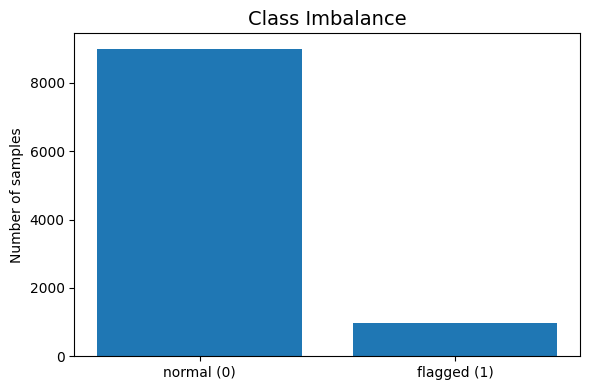

Imbalance ratio (bad/good): 0.11


In [213]:
class_counts = pd.Series(y).value_counts().sort_index()
class_names  = ["normal (0)", "flagged (1)"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_names, class_counts.values)
ax.set_title("Class Imbalance", fontsize=14)
ax.set_ylabel("Number of samples")
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts[1] / class_counts[0]
print(f"Imbalance ratio (bad/good): {imbalance_ratio:.2f}")

Such a ratio needs weighting during training

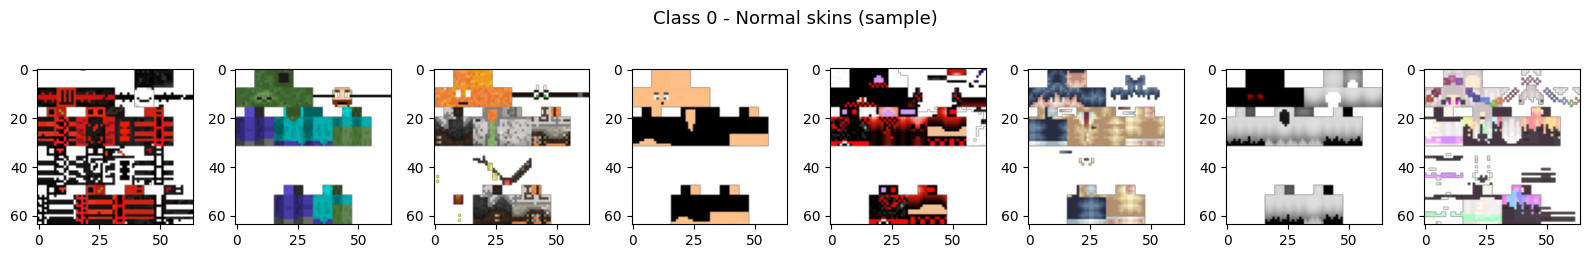

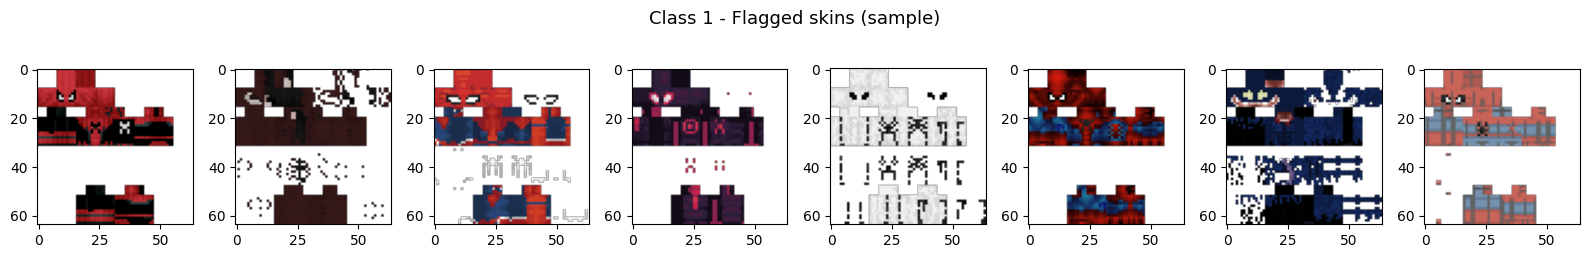

In [214]:
def show_samples(X, y, label, n=8, title=""):
    indices = np.where(y == label)[0]
    chosen  = np.random.choice(indices, size=min(n, len(indices)), replace=False)

    fig, axes = plt.subplots(1, len(chosen), figsize=(2 * len(chosen), 2.5))
    fig.suptitle(title, fontsize=13)
    for ax, idx in zip(axes, chosen):
        ax.imshow(X[idx, :, :, :4])
    plt.tight_layout()
    plt.show()

show_samples(X, y, label=0, n=8, title="Class 0 - Normal skins (sample)")
show_samples(X, y, label=1, n=8, title="Class 1 - Flagged skins (sample)")

A normal looking skin was labeled as spiderman. Apparently the scraped data is not clean enough. We hope that the model can converge and we will check bad false negatives later to swap the labels and re-train

## 6. Train / Validation / Test Split

We use a **stratified** split to ensure the class ratio is preserved in all 3 sets.

In [215]:
# split off test set and preserve it for the end
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=TEST_SPLIT,
    stratify=y, # preserve class ratio
    random_state=SEED
)

# split training into train + validation
val_relative = VAL_SPLIT / (1 - TEST_SPLIT) # should be around 0,176
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_relative,
    stratify=y_trainval,
    random_state=SEED
)

print(f"Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass 1 ratio in train: {y_train.mean():.3f}") # we can just take the mean as we only have two classes
print(f"Class 1 ratio in val: {y_val.mean():.3f}")
print(f"Class 1 ratio in test: {y_test.mean():.3f}")

Train: 6,972 samples (70%)
Val: 1,494 samples (15%)
Test: 1,495 samples (15%)

Class 1 ratio in train: 0.097
Class 1 ratio in val: 0.096
Class 1 ratio in test: 0.096


## 7. Handling Class Imbalance

### Problem

If Class 0 has far more samples than Class 1, a naïve model can achieve high accuracy  
simply by predicting Class 0 for every sample. This is called the **majority-class baseline**.

### Solution: Inverse-frequency class weights
https://www.geeksforgeeks.org/deep-learning/how-to-handle-class-imbalance-in-tensorflow/

We compute weights `w_k = total_samples / (n_classes × count_k)` for each class k.
These weights are passed to `model.fit()` so that errors on the minority class  
count proportionally more in the loss function.  

This is equivalent to **oversampling** the minority class in expectation,  
but requires no data duplication.

In [216]:
n_total = len(y_train)
n_good = int((y_train == 0).sum())
n_bad = int((y_train == 1).sum())
n_classes = 2

# inverse-frequency weighting
class_weights = {
    0: n_total / (n_classes * n_good),
    1: n_total / (n_classes * n_bad),
}

print("Class weights:")
print(class_weights)
print(f"misclassifying a flagged skin costs {class_weights[1]/class_weights[0]}x more than misclassifying a normal skin.")

Class weights:
{0: 0.5534211779647563, 1: 5.179791976225855}
misclassifying a flagged skin costs 9.35958395245171x more than misclassifying a normal skin.


## Data Augmentation

Augmentation artificially increases training diversity, which reduces overfitting and improves generalization to unseen skins.

### What NOT to do with Minecraft skins

Standard augmentations like **horizontal flipping**, **rotation**, or **translation** would break the semantic structure of a Minecraft skin.

The skin format has fixed pixel regions (head: top-left area, body: center, etc.). See below

Shifting the image would move, e.g., the head region into the arm region, creating unwanted inputs that confuse the model.


- **Channel shift / hue phase shifting**: the exact color hue is less class-discriminative
  than the pattern shape

Augmentation is **only applie to the training set** and never to val/test,
because validation and test must reflect the real-world data distribution.

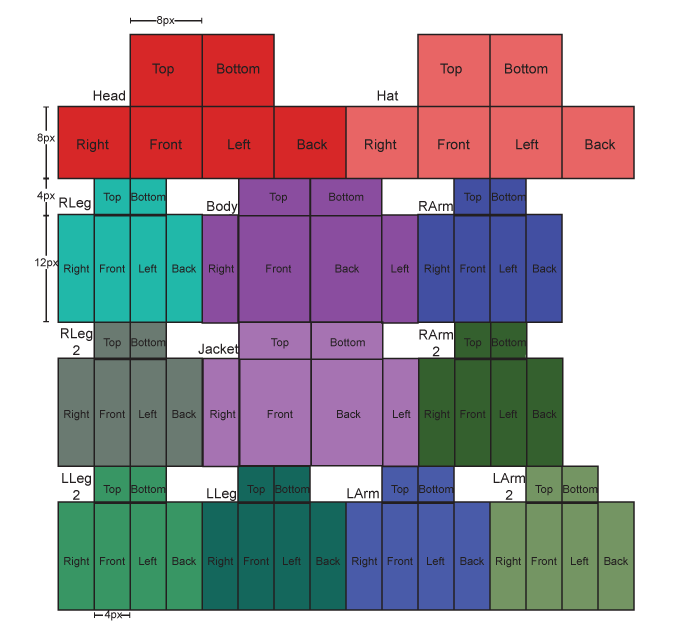

https://www.tensorflow.org/tutorials/images/data_augmentation#data_augmentation_2

In [217]:
import tensorflow as tf
from tensorflow.keras import layers

SHIFT_VAL = 25 / 255 # 10% random color shifts for all images

data_augmentation = tf.keras.Sequential([
    layers.Lambda(lambda x: tf.concat([
        tf.clip_by_value(x[..., :3] + tf.random.uniform(tf.shape(x[..., :3]), -SHIFT_VAL, SHIFT_VAL), 0.0, 1.0),
        # mask the R, G, B Values from x and add random noise to it in the range from SHIFT_VAL, clip it inbetween 0 and 1
        x[..., 3:4] # the alpha value
    ], axis=-1)),
    layers.GaussianNoise(0.1),
])

## Baseline Model

Before training a neural network, we establish a **baseline** the simplest possible model.
This serves as a reference: our CNN must clearly outperform it to justify its complexity.

It is literally based on the class imbalance.
If the model predicts better than a class-weighted random guess, it is better

**Majority class baseline:** predict the most frequent class for every input.
It requires no training but reveals the naive upper bound for accuracy on imbalanced data.

In [218]:
majority_class = np.bincount(y_train.astype(int)).argmax()
baseline_preds = np.full(len(y_test), majority_class) # only class 0 guesses
baseline_acc = (baseline_preds == y_test).mean() # but comparing it with the real labels -> high accuracy
baseline_recall = ((baseline_preds == 1) & (y_test == 1)).sum() / (y_test == 1).sum() # recall is extremly bad!

print(f"Majority class: {majority_class}")
print(f"Accuracy: {baseline_acc}")
print(f"Recall (class 1): {baseline_recall}")

Majority class: 0
Accuracy: 0.9036789297658863
Recall (class 1): 0.0


## CNN

The CNN was adapted from the MNIST CNN example notebook and enhanced for the minecraft skin data

In [219]:
model = Sequential([
        Input(shape=(IMG_SIZE[0], IMG_SIZE[1], N_CHANNELS)),

        data_augmentation,

        # low level patterns
        Conv2D(16, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(16, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.4),

        # mid-level patterns
        Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.4),

        # high level patterns
        Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.4),

        GlobalAveragePooling2D(), # reduce parameters
        Dense(64, activation="relu"),
        Dropout(0.6), # prevent overfit
        Dense(1, activation="sigmoid"),
    ], name="minecraft_skin_cnn")

model.summary()

Model: "minecraft_skin_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_10 (Sequential)      │ (None, 64, 64, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 64, 64, 16)     │           592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 77,345 (302.13 KB)

 Trainable params: 76,897 (300.38 KB)

 Non-trainable params: 448 (1.75 KB)

## Model Compilation

### Metrics tracked during training
- **Precision / Recall** - directly measure false-positive and false-negative rates  
- **Accuracy** - kept for comparison with baseline

In [220]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_INIT),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

## Early Stopping and other training callbacks


In [221]:
callbacks = [
    EarlyStopping(
        monitor="val_auc",
        mode="max", # we want to maximize AUC
        patience=PATIENCE,
        restore_best_weights=True, # revert to best epoch after stopping
        verbose=1,
    ),
    ModelCheckpoint( # https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint
        filepath=str(MODEL_PATH),
        monitor="val_auc",
        mode="max", # we want to maximize auc
        save_best_only=True,
        verbose=0,
    ),
]

## Model Training

We pass class weights to every sample to give the minority class proportionally higher loss.
Training will stop automatically when the validation loss stops improving (EarlyStopping).

In [222]:
sample_weights = np.where(y_train == 1, class_weights[1], class_weights[0])
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train, sample_weights))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [223]:
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"Training stopped after {len(history.history['loss'])} epochs.")

Epoch 1/30
218/218 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.7212 - auc: 0.7942 - loss: 0.5929 - precision: 0.2194 - recall: 0.7385 - val_accuracy: 0.9036 - val_auc: 0.8378 - val_loss: 0.3004 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
218/218 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.8194 - auc: 0.8836 - loss: 0.4563 - precision: 0.3241 - recall: 0.8024 - val_accuracy: 0.9137 - val_auc: 0.8826 - val_loss: 0.2821 - val_precision: 0.6596 - val_recall: 0.2153
Epoch 3/30
218/218 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.8276 - auc: 0.8962 - loss: 0.4277 - precision: 0.3372 - recall: 0.8143 - val_accuracy: 0.9210 - val_auc: 0.8592 - val_loss: 0.2924 - val_precision: 0.6757 - val_recall: 0.3472
Epoch 4/30
218/218 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - accuracy: 0.8501 - auc: 0.9073 - loss: 0.4086 - precision: 0.3743 - recall: 0.8232 - val_accuracy: 0.9096 - val_auc: 0.8960 - val_loss: 0.2563 - val_precision: 0.5310 - val_recall: 0.5347
Epoch 5/30
218/

## 14. Training Curves

We plot loss and key metrics over epochs to assess:
- Whether the model **converged** (curves flatten)
- Whether there is **overfitting** (train improves, val stagnates or worsens)

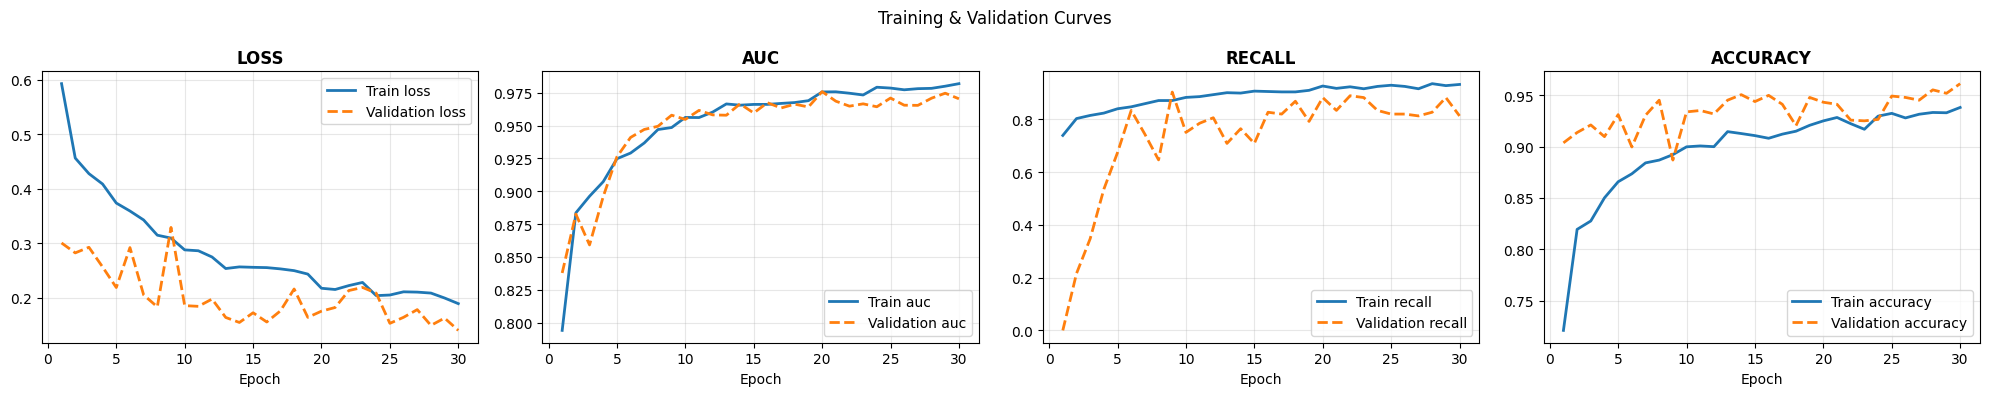

In [231]:
def plot_history(history, metrics=("loss", "auc", "recall", "accuracy")):
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    epochs = range(1, len(history.history["loss"]) + 1)

    for ax, metric in zip(axes, metrics):
        ax.plot(epochs, history.history[metric], label=f"Train {metric}", linewidth=2)
        ax.plot(epochs, history.history[f"val_{metric}"], label=f"Validation {metric}", linewidth=2, linestyle="--")
        ax.set_title(metric.upper(), fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle("Training & Validation Curves")
    plt.tight_layout()
    plt.show()

plot_history(history)

---
## 15. Evaluation on Test Set

We now evaluate the model on the **held-out test set** - data the model has never seen  
in any form (not for training, not for early stopping, not for LR scheduling).

This gives an unbiased estimate of real-world performance.

In [225]:
# Get predicted probabilities (not hard labels yet)
y_prob = model.predict(X_test, verbose=0).ravel()

# Default threshold = 0.5
y_pred_default = (y_prob >= 0.5).astype(int)

# Metrics
auc  = roc_auc_score(y_test, y_prob)
print("=" * 45)
print(f"AUC-ROC         : {auc:.4f}")
print("=" * 45)
print(classification_report(y_test, y_pred_default, target_names=["normal", "flagged"]))

AUC-ROC         : 0.9693
              precision    recall  f1-score   support

      normal       0.99      0.96      0.97      1351
     flagged       0.71      0.88      0.79       144

    accuracy                           0.95      1495
   macro avg       0.85      0.92      0.88      1495
weighted avg       0.96      0.95      0.96      1495



### Confusion Matrix

The confusion matrix shows the four types of predictions:
- **True Negatives (TN)**: correctly classified as normal  
- **False Positives (FP)**: normal skin wrongly flagged → minor inconvenience  
- **False Negatives (FN)**: flagged skin missed → ⚠️ the error we most want to minimize  
- **True Positives (TP)**: correctly detected flagged skin

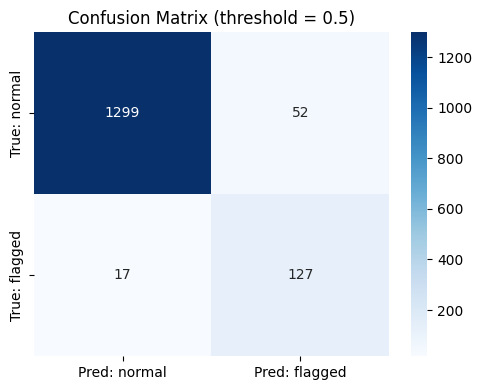

True Negatives (correct normal) : 1299
False Positives (normal→flagged): 52  ← recoverable error
False Negatives (flagged→normal): 17  ← ⚠️ critical error
True Positives (correct flagged): 127


In [226]:
cm = confusion_matrix(y_test, y_pred_default)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: normal", "Pred: flagged"],
    yticklabels=["True: normal", "True: flagged"],
    ax=ax
)
ax.set_title("Confusion Matrix (threshold = 0.5)", fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correct normal) : {tn}")
print(f"False Positives (normal→flagged): {fp}  ← recoverable error")
print(f"False Negatives (flagged→normal): {fn}  ← ⚠️ critical error")
print(f"True Positives (correct flagged): {tp}")

---
## 16. Threshold Tuning

The default decision threshold of **0.5** is not always optimal, especially when  
one error type is more costly than the other.

Since we want to **maximise recall** (catch as many flagged skins as possible)  
we sweep all possible thresholds and find the one that maximises F1-score on the **validation set**.  
Using the validation set (not test set) for threshold tuning prevents data leakage.

The **Precision-Recall curve** shows the trade-off: lowering the threshold  
increases recall but decreases precision.

Best threshold (max F1 on val): 0.765
  → F1       : 0.7986
  → Recall   : 0.8125
  → Precision: 0.7852


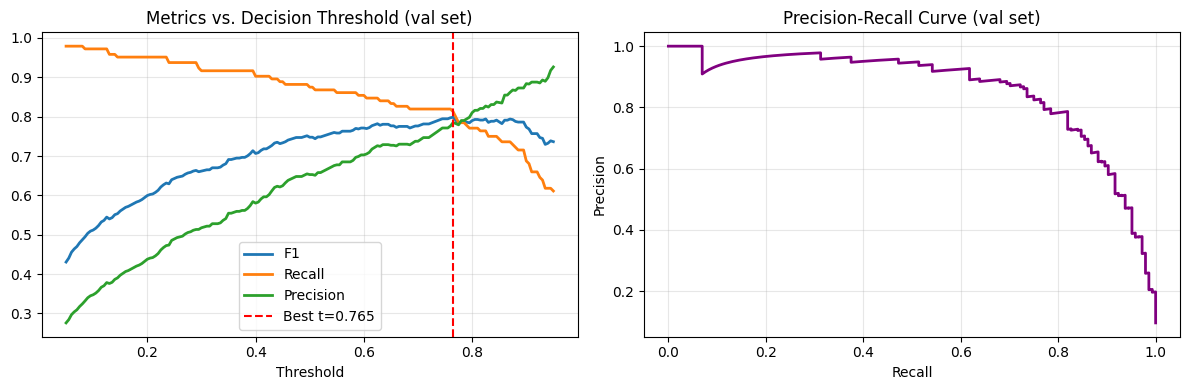

In [227]:
# --- 1. Compute threshold sweep on VALIDATION set ---
y_prob_val = model.predict(X_val, verbose=0).ravel()

thresholds = np.linspace(0.05, 0.95, 181)
results = []
for t in thresholds:
    y_hat = (y_prob_val >= t).astype(int)
    f1  = f1_score(y_val, y_hat, zero_division=0)
    rec = ((y_hat == 1) & (y_val == 1)).sum() / max((y_val == 1).sum(), 1)
    pre = ((y_hat == 1) & (y_val == 1)).sum() / max((y_hat == 1).sum(), 1)
    results.append({"threshold": t, "f1": f1, "recall": rec, "precision": pre})

results_df  = pd.DataFrame(results)
best_row    = results_df.loc[results_df["f1"].idxmax()]
BEST_THRESH = best_row["threshold"]

print(f"Best threshold (max F1 on val): {BEST_THRESH:.3f}")
print(f"  → F1       : {best_row['f1']:.4f}")
print(f"  → Recall   : {best_row['recall']:.4f}")
print(f"  → Precision: {best_row['precision']:.4f}")

# --- 2. Visualise the sweep ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# F1 / Recall / Precision vs Threshold
axes[0].plot(results_df["threshold"], results_df["f1"],        label="F1",        linewidth=2)
axes[0].plot(results_df["threshold"], results_df["recall"],    label="Recall",    linewidth=2)
axes[0].plot(results_df["threshold"], results_df["precision"], label="Precision", linewidth=2)
axes[0].axvline(BEST_THRESH, color="red", linestyle="--", label=f"Best t={BEST_THRESH:.3f}")
axes[0].set_xlabel("Threshold")
axes[0].set_title("Metrics vs. Decision Threshold (val set)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
prec_curve, rec_curve, _ = precision_recall_curve(y_val, y_prob_val)
axes[1].plot(rec_curve, prec_curve, linewidth=2, color="purple")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (val set)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Final Test Evaluation (threshold = 0.765) ===
              precision    recall  f1-score   support

      normal       0.98      0.98      0.98      1351
     flagged       0.79      0.81      0.80       144

    accuracy                           0.96      1495
   macro avg       0.89      0.89      0.89      1495
weighted avg       0.96      0.96      0.96      1495



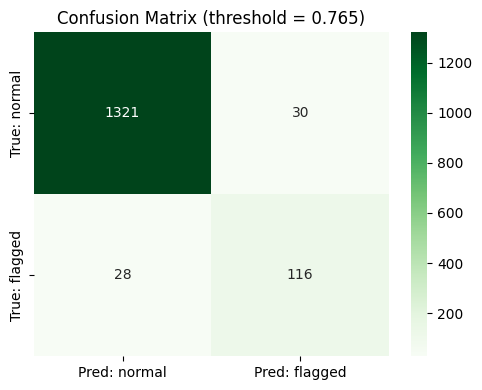

In [228]:
# ── Final evaluation on TEST set with tuned threshold ────────────────────────
y_pred_tuned = (y_prob >= BEST_THRESH).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f"=== Final Test Evaluation (threshold = {BEST_THRESH:.3f}) ===")
print(classification_report(y_test, y_pred_tuned, target_names=["normal", "flagged"]))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_tuned, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Pred: normal", "Pred: flagged"],
    yticklabels=["True: normal", "True: flagged"],
    ax=ax
)
ax.set_title(f"Confusion Matrix (threshold = {BEST_THRESH:.3f})", fontsize=12)
plt.tight_layout()
plt.show()

---
## 17. Error Analysis

Visualising the mistakes the model makes helps understand where it struggles  
and how it could be improved in a next iteration.

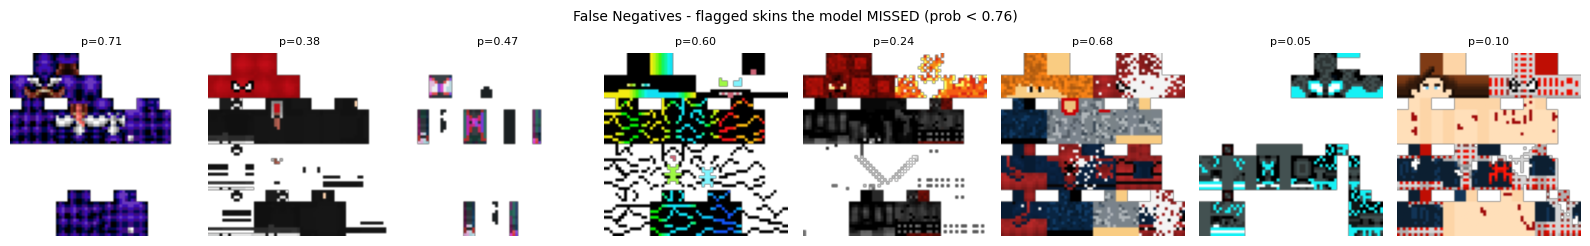

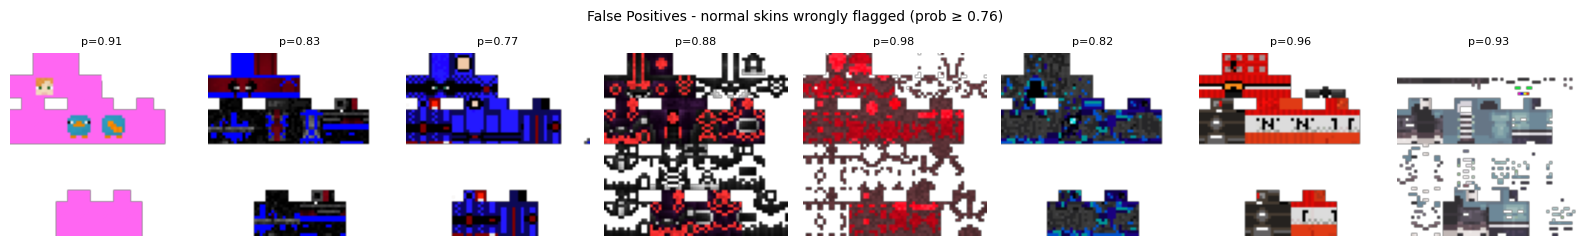

In [229]:
def show_errors(X_test, y_test, y_pred, y_prob, error_type="fn", n=8, threshold=0.5):
    """
    Show misclassified samples.
    error_type: 'fn' = false negatives (missed flagged skins)
                'fp' = false positives (normal skins wrongly flagged)
    """
    if error_type == "fn":
        mask  = (y_test == 1) & (y_pred == 0)
        title = f"False Negatives - flagged skins the model MISSED (prob < {threshold:.2f})"
    else:
        mask  = (y_test == 0) & (y_pred == 1)
        title = f"False Positives - normal skins wrongly flagged (prob ≥ {threshold:.2f})"

    indices = np.where(mask)[0]
    if len(indices) == 0:
        print(f"No {error_type.upper()} errors found!")
        return

    chosen = np.random.choice(indices, size=min(n, len(indices)), replace=False)
    fig, axes = plt.subplots(1, len(chosen), figsize=(2 * len(chosen), 2.5))
    fig.suptitle(title, fontsize=10)
    if len(chosen) == 1:
        axes = [axes]
    for ax, idx in zip(axes, chosen):
        ax.imshow(X_test[idx, :, :, :4])
        ax.set_title(f"p={y_prob[idx]:.2f}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_errors(X_test, y_test.astype(int), y_pred_tuned, y_prob, error_type="fn", threshold=BEST_THRESH)
show_errors(X_test, y_test.astype(int), y_pred_tuned, y_prob, error_type="fp", threshold=BEST_THRESH)

---
## 18. Results Summary & Comparison

We compare all models / thresholds against the majority-class baseline.

In [230]:
from sklearn.metrics import precision_score, recall_score

def eval_row(name, y_true, y_pred, y_prob=None):
    row = {
        "Model": name,
        "Accuracy" : (y_pred == y_true).mean(),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1"       : f1_score(y_true, y_pred, zero_division=0),
        "AUC"      : roc_auc_score(y_true, y_prob) if y_prob is not None else "-",
    }
    return row

summary = pd.DataFrame([
    eval_row("Majority Baseline",       y_test.astype(int), baseline_preds),
    eval_row("CNN (threshold=0.5)",     y_test.astype(int), y_pred_default, y_prob),
    eval_row(f"CNN (threshold={BEST_THRESH:.3f})", y_test.astype(int), y_pred_tuned, y_prob),
])

# Format numeric columns
for col in ["Accuracy", "Precision", "Recall", "F1"]:
    summary[col] = summary[col].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)

print(summary.to_string(index=False))

                Model Accuracy Precision Recall     F1       AUC
    Majority Baseline   0.9037    0.0000 0.0000 0.0000         -
  CNN (threshold=0.5)   0.9538    0.7095 0.8819 0.7864  0.969297
CNN (threshold=0.765)   0.9612    0.7945 0.8056 0.8000  0.969297


---
## 19. Conclusion & Key Learnings

### What we built

A binary CNN classifier for Minecraft skin images (64×64 RGBA) that detects  
copyrighted/banned character skins with high reliability.

### Key design decisions and why they matter

| Decision | Impact |
|---|---|
| Keeping the **alpha channel** as input | Alpha encodes skin regions - structural information for the model |
| **Class weighting** | Counteracts imbalance without data duplication |
| **No flipping/rotation augmentation** | Preserves the fixed spatial structure of the skin format |
| **GlobalAveragePooling** instead of Flatten | Fewer parameters, less overfitting |
| **EarlyStopping + ReduceLROnPlateau** | Prevents overfitting, improves convergence stability |
| **Threshold tuning on validation set** | Optimises recall without leaking test set information |

### Limitations & future work

- Currently trained only on **Spider-Man** as the bad class → more keyword classes would improve generalization  
- **Focal Loss** could replace class weighting for even stronger handling of hard examples  
- **Hyperparameter search** (Bayesian optimisation) over dropout rates, LR, architecture depth  
- **Region-based CNN**: train separate heads for head, body, arms, legs regions (exploits known skin layout)  
- **Explainability**: Grad-CAM heatmaps to visualise which skin regions drive the prediction

In [45]:
# Save the final model
model.save(str(MODEL_PATH) + "_10k_saturday" + ".keras")
print(f"Model saved to: {MODEL_PATH}")

Model saved to: ..\04_Modeling\best_model
